In [20]:
from sage.all import *

In [2]:
def supersingular_isogeny_graph(p, l):
    """        
    Constructs the supersingular ℓ-isogeny graph without additional level structures.
    
    Parameters:
        p   : prime
        ell : isogeny degree
        
    Returns:
        A multigraph with vertices (j-invariant)
    """
    Fp2 = GF(p^2, 'a')
    
    S = SupersingularModule(p)
    j_invariants, _ = S.supersingular_points()

    supersingular_curves = []
    for j in j_invariants:
        try:
            E = EllipticCurve_from_j(j).change_ring(Fp2)
            supersingular_curves.append((j, E))
        except ArithmeticError:
            pass
        
    G = Graph(multiedges=True, loops=True)
    G.add_vertices(j_invariants)

    added_edges = set()

    for j, E in supersingular_curves:
        isogenies = E.isogenies_prime_degree(l)

        for iso in isogenies:
            j_target = iso.codomain().j_invariant()
            if j_target not in j_invariants:
                continue
            #avoid dual isogenies
            if j <= j_target:
                G.add_edge(j, j_target)
                
    G.show(layout='circular', vertex_size=400, edge_labels=False)
    return G





In [ ]:
def get_torsion_bases(p, N):
    F = GF(p^2, 'a')
    K = F.extension(6, 'a')
    
    S = SupersingularModule(p)
    j_invariants, _ = S.supersingular_points()
    
    torsion_data = {}

    for j in j_invariants:
        E =  EllipticCurve(K, j=j)
        basis = E.torsion_basis(N)
        torsion_data[j] = (E, basis) 
        
    return torsion_data



def generate_order_N_subgroups(torsion_data, N):
    subgroup_data = {}
    
    for j, (E, [P, Q]) in torsion_data.items():
        subgroups = {}
        idx = 0
        seen = set() 

        for a in range(N):
            for b in range(N):
                if a == 0 and b == 0:
                    continue
                    
                G = [k * (a * P + b * Q) for k in range(N)]
                G_set = frozenset(G)
                
                if len(G_set) == N and G_set not in seen:
                    subgroups[f'G{idx}'] = G_set
                    seen.add(G_set)
                    idx += 1

        subgroup_data[j] = subgroups

    return subgroup_data

def construct_level_N_graph(torsion_data, subgroup_data, p, ell):
    F = GF(p^2, 'a')
    edges = []

    for j1, (E1, _) in torsion_data.items():
        groups1 = subgroup_data[j1]

        isogenies = E1.isogenies_prime_degree(ell)

        for isogeny in isogenies:
            j2 = F(isogeny.codomain().j_invariant())

            if j2 not in torsion_data:
                continue

            E2 = torsion_data[j2][0]
            
            #isomorphism composition to map the points to the correct curve
            isomorphism_isogeny = isogeny.codomain().isomorphism_to(E2) * isogeny
            
            groups2 = subgroup_data[j2]
            
            for label1, G1 in groups1.items():
                image_G1 = set(isomorphism_isogeny(P) for P in G1)

                for label2, G2 in groups2.items():
                    #do not count dual isogenies 
                    if image_G1 == G2 and (j1 < j2 or (j1 == j2 and label1 <= label2)):
                        v1 = str((j1, label1))
                        v2 = str((j2, label2))
                        edges.append((v1, v2))

    return Graph(edges, multiedges=True, loops=True)

def supersingular_isogeny_graph_with_levels(p, ell, N):
    """
    Constructs the supersingular l-isogeny graph with level-N structures.
    
    Parameters:
        p   : prime
        ell : isogeny degree
        N   : level structure order 
        
    Returns:
        A multigraph with vertices (j-invariant, subgroup label)
    """
    torsion_data = get_torsion_bases(p, N)
    subgroup_data = generate_order_N_subgroups(torsion_data, N)
    G = construct_level_N_graph(torsion_data, subgroup_data, p, ell)
    return G


In [4]:
def ihara_zeta(G):
    """
    Constructs the Ihara zeta function of a supersingular isogeny graph. 
    
    Parameters:
        G   : (l+1)-regular, connected, finite graph
    Returns:
        The Ihara zeta function of G
    """
    #using polynomial ring to speed up determinant computations
    R.<t> = PolynomialRing(QQ, 't')

    A = G.adjacency_matrix()
    
    q = sum(A[0]) - 1
    Q = Matrix(diagonal_matrix([q for v in G.vertices()]))
    
    num_vertices = G.num_verts()
    
    
    chi_G = (num_vertices * (1-q)) / 2 
    
    I = identity_matrix(A.nrows())  
    det_term = (I - A*t + Q*t^2).determinant()

    
    zeta_G = SR((1 - t^2)) ^ chi_G / SR(det_term)
    zeta_G = zeta_G.simplify_full()

    return zeta_G


In [5]:
def modular_curve_zeta_function(p, l, N):
    """
    Constructs the Hasse-Weil of the modular curve X0(pN) defined over F_l. 
    
    Parameters:
        p: the level of the modular curve
        l: characteristic of the field over which the curve is defined. Typically corresponds to the degree of the isogeny in the related graph
        N: N corresponds to the level-N structure in the graph. if not using level structures, use N = 1.
        
    Returns:
        The Hasse Weil zeta function of the modular curve X0(pN) defined over F_l
    """
    t =  var("t") 
    
    B_l = BrandtModule(p, N).hecke_matrix(l)
    
    eigenvalues = B_l.eigenvalues()
    eigenvalues_filtered = [λ.n(digits=10) for λ in eigenvalues if λ != l + 1]
    
    P_t = prod(1 - λ * t + l * t^2 for λ in eigenvalues_filtered)
    D_t = (1 - t) * (1 - l * t)
    Z_X = P_t / D_t

    return Z_X.simplify_full()

In [6]:
def zeta_product_no_levels(p, l):
    """
    Constructs the right hand side the product relation derived by Sugiyama
    
    Parameters:
        p: prime p corresponding to the graph G(p, l)
        l: the isogeny degree in G(p, l)
    Returns:
        The right hand side of the product of the Ihara zeta function of G(p,l) and the Hasse-Weil zeta function of X0(p) over Fl
    """
    t = var('t')
    
    n = (p - 1) / 12
    
    expected_product = 1 / (((-t + 1)**2) * ((1 - l*t)**2) * ((1 - t**2)**((n * (l - 1)) / 2)))
    
    return expected_product 

In [7]:
def zeta_product_with_levels(G):
    """
    Constructs the right hand side the product relation derived by Lei and Müller
    
    Parameters:
        G: G(p, l, N) a supersingular l-isogeny graph with level-N structure
    Returns:
        The right hand side of the product of the Ihara zeta function of G(p,l, N) and the Hasse-Weil zeta functions of X0(N) and X0(pN)
    """
    num_vertices = G.num_verts()
    
    A = G.adjacency_matrix()
    
    q = sum(A[0]) - 1
    
    chi_G = (num_vertices * (1-q)) / 2 
    
    t= var("t")
    
    expected_product = (1 - t^2)^chi_G 
    
    return expected_product

Supersingular 2-isogeny graph:


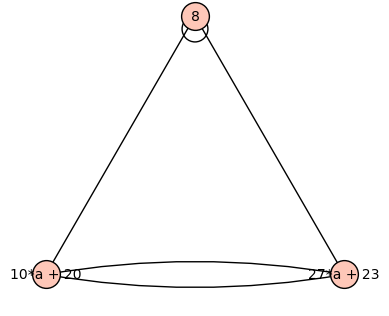


Adjacency matrix:
[1 1 1]
[1 0 2]
[1 2 0]

Ihara zeta function:


-1/((8*t^8 - 4*t^7 - 8*t^6 + 3*t^3 + t^2 + t - 1)*sqrt(-t^2 + 1))


Hasse–Weil zeta function of X₀(37):


(4*t^4 + 4.0*t^3 + 4*t^2 + 2.0*t + 1)/(2*t^2 - 3*t + 1)


Product of Hasse–Weil and Ihara zeta functions:


...

90.2025009242693


RHS (product formula without level structure):


1/((-t^2 + 1)^(3/2)*(2*t - 1)^2*(t - 1)^2)


RHS evaluated at t = 0.4:


90.2025009242694

In [10]:
p = 37
l = 2
N = 1

print(f"Supersingular {l}-isogeny graph:")
G = supersingular_isogeny_graph(p=p, l=l)
G.plot()

print("\nAdjacency matrix:")
print(G.adjacency_matrix())

print("\nIhara zeta function:")
ihara_zeta_func = ihara_zeta(G)
ihara_zeta_func.show()

print(f"\nHasse–Weil zeta function of X₀({p}):")
hasse_weil_zeta = modular_curve_zeta_function(p, l, N)
hasse_weil_zeta.show()

print("\nProduct of Hasse–Weil and Ihara zeta functions:")
LHS = (hasse_weil_zeta * ihara_zeta_func).simplify_full()
LHS.show()

print("\nLHS valuated at t = 0.4:")
show(LHS.subs(t=0.4))

print("\nRHS (product formula without level structure):")
RHS = zeta_product_no_levels(p, l)
RHS.show()

print("\nRHS evaluated at t = 0.4:")
show(RHS.subs(t=0.4))

In [14]:
p = 61
l = 2
N = 3

print(f"Supersingular {l}-isogeny graph with level-3 structure:")
G = supersingular_isogeny_graph_with_levels(p=p, ell=l, N=N)
G.plot()

print("\nAdjacency matrix:")
print(G.adjacency_matrix())

print("\nIhara zeta function:")
ihara_zeta_func = ihara_zeta(G)
ihara_zeta_func.show()

print(f"\nHasse–Weil zeta function of X₀({N}):")
hasse_weil_zeta_at_N = modular_curve_zeta_function(p=N, l=l, N=1)
hasse_weil_zeta_at_N.show()

print(f"\nHasse–Weil zeta function of X₀(pN):")
hasse_weil_zeta_at_pN = modular_curve_zeta_function(p=p, l=l, N=N)
hasse_weil_zeta_at_pN.show()


print("\nProduct of Hasse–Weil and Ihara zeta functions:")
LHS = (hasse_weil_zeta_at_pN * hasse_weil_zeta_at_N^-2 * ihara_zeta_func).simplify_full()
LHS.show()

print("\nLHS valuated at t = 0.4:")
show(LHS.subs(t=0.4))

print("\nRHS (product formula with level structure):")
RHS = zeta_product_with_levels(G)
RHS.show()

print("\nRHS evaluated at t = 0.4:")
show(RHS.subs(t=0.4))

Supersingular 2-isogeny graph with level-3 structure:



Adjacency matrix:
[0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1]
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0]
[0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0]
[0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1]
[1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0]
[0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0]
[0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0]
[0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0]
[0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0]
[1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0]
[0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
[0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0]
[0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
[0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0]
[0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0]
[0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
[1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]

Ihara zeta function:


1/(1048576*t^60 - 1048576*t^59 - 7340032*t^58 + 7077888*t^57 + 21037056*t^56 - 18743296*t^55 - 30998528*t^54 + 22446080*t^53 + 23863296*t^52 - 6610944*t^51 - 8638464*t^50 - 10457088*t^49 + 1473024*t^48 + 7052288*t^47 + 942848*t^46 + 3506048*t^45 - 3737392*t^44 - 3398544*t^43 + 2183488*t^42 + 126180*t^41 + 1035029*t^40 - 601110*t^39 - 630202*t^38 + 600462*t^37 - 365922*t^36 + 197290*t^35 - 11462*t^34 - 74674*t^33 + 109861*t^32 - 57928*t^31 + 57072*t^30 - 34280*t^29 - 23744*t^28 + 12520*t^27 + 1744*t^26 + 8768*t^25 - 6702*t^24 - 1956*t^23 + 332*t^22 + 420*t^21 + 236*t^20 + 492*t^19 - 332*t^18 + 132*t^17 + 26*t^16 - 8*t^15 + 128*t^14 - 200*t^13 + 96*t^12 + 24*t^11 + 12*t^9 - 39*t^8 + 10*t^7 - 2*t^6 - 2*t^5 + 6*t^4 - 6*t^3 + 2*t^2 - 2*t + 1)


Hasse–Weil zeta function of X₀(3):


1/(2*t^2 - 3*t + 1)

...

5.71751271919045


RHS (product formula with level structure):


(t^2 - 1)^(-10)


RHS evaluated at t = 0.4:


5.71751271878145

In [22]:
#SIDH toy example

p = 97
lA, eA = 2, 2
lB, eB = 3, 1

F = GF(p^2, 'a')

S = SupersingularModule(p)
j_invariants, _ = S.supersingular_points()
print("j-invariants:", j_invariants)

a = F.gen()  
j = 81*a + 84
E = EllipticCurve(F, j=j)

PA, QA = E.torsion_basis(lA^eA)
PB, QB = E.torsion_basis(lB^eB)

print("P_A:", PA)
print("Q_A:", QA)
print("P_B:", PB)
print("Q_B:", QB)

mA, nA = 1, 2
mB, nB = 2, 1

A = mA * PA + nA * QA
B = mB * PB + nB * QB
print("Secret A:", A)
print("Secret B:", B)
phi_A = E.isogeny(A)
E_A = phi_A.codomain()

phi_B = E.isogeny(B)
E_B = phi_B.codomain()

print("j(E_A):", E_A.j_invariant())
print("j(E_B):", E_B.j_invariant())

phiA_PB = phi_A(PB)
phiA_QB = phi_A(QB)
phiB_PA = phi_B(PA)
phiB_QA = phi_B(QA)

print("φ_A(P_B):", phiA_PB)
print("φ_A(Q_B):", phiA_QB)
print("φ_B(P_A):", phiB_PA)
print("φ_B(Q_A):", phiB_QA)

shared_A = mA * phiB_PA + nA * phiB_QA
shared_B = mB * phiA_PB + nB * phiA_QB

print("shared_A:", shared_A)
print("shared_B:", shared_B)

final_curve_A = E_B.isogeny(shared_A).codomain()
final_curve_B = E_A.isogeny(shared_B).codomain()

print("Shared j-invariant (Alice):", final_curve_A.j_invariant())
print("Shared j-invariant (Bob):  ", final_curve_B.j_invariant())



j-invariants: [1, 20, 81*a + 84, 16*a + 68, 20*a + 35, 77*a + 55, 12*a + 75, 85*a + 87]
P_A: (5*a + 69 : 60*a + 12 : 1)
Q_A: (40*a + 58 : 48*a + 73 : 1)
P_B: (93*a + 73 : 94*a + 1 : 1)
Q_B: (39*a + 79 : 30*a + 29 : 1)
Secret A: (53*a + 9 : 87*a + 14 : 1)
Secret B: (68*a + 12 : 82*a + 41 : 1)
j(E_A): 12*a + 75
j(E_B): 85*a + 87
φ_A(P_B): (72*a + 44 : 86*a + 48 : 1)
φ_A(Q_B): (14*a + 11 : 35*a + 30 : 1)
φ_B(P_A): (27*a + 85 : 6*a + 70 : 1)
φ_B(Q_A): (85*a + 27 : 56*a + 2 : 1)
shared_A: (74*a + 78 : 68*a + 85 : 1)
shared_B: (96*a + 57 : 88*a + 59 : 1)
Shared j-invariant (Alice): 16*a + 68
Shared j-invariant (Bob):   16*a + 68
